In [1]:
import numpy as np
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
import math


def plot_images(images, nrows=1, ncols=5, cmap='gray', figsize=(20, 10), filename=None):
    """
    Plot a list of images using matplotlib subplots.

    Args:
        images (list or np.ndarray): List or array of images to plot.
        nrows (int): Number of rows in the subplot grid.
        ncols (int): Number of columns in the subplot grid.
        cmap (str): Color map for the images (e.g., 'gray', 'viridis').
        figsize (tuple): Tuple specifying the overall figure size (width, height).
    """
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = axes.flatten()

    # Iterate through all the subplots
    for i, ax in enumerate(axes):
        if i < len(images):  # Plot if there are images left
            ax.imshow(images[i], cmap=cmap)
            ax.axis('off')  # Turn off axes
        else:  # Turn off any extra axes (used when images < nrows*ncols)
            ax.axis('off')

    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=300)
    plt.show()


def show_reconstructions_code(model, images, shape, n_images=5, **kwargs):
    code = model.layers[0].predict(images[:n_images])
    code_images = code.reshape([n_images] + list(shape))
    reconstructed_images = model.layers[1].predict(code)
    # all_images = np.append(images, reconstructed_images, axis=0)
    all_images = [x for x in images[:n_images]]
    all_images.extend(code_images)
    all_images.extend(reconstructed_images)
    plot_images(all_images, nrows=3, **kwargs)


def show_code_reconstructions(decoder, codes, n_images=5, shape=None):
    code_shape = (1, codes.shape[1])
    reconstructions = decoder.predict(codes[:n_images])
    reconstructed_images = reconstructions if shape is None else reconstructions.reshape([n_images] + list(shape))
    all_images = [x.reshape(code_shape) for x in codes]
    all_images.extend(reconstructed_images)
    plot_images(all_images, nrows=2)


def plot_reconstructions(model, images, n_images=5):
    reconstructions = np.clip(model.predict(images[:n_images]), 0, 1)
    fig = plt.figure(figsize=(n_images * 1.5, 3))
    for image_index in range(n_images):
        plt.subplot(2, n_images, 1 + image_index)
        plt.imshow(images[image_index], cmap="binary")
        plt.axis("off")
        plt.subplot(2, n_images, 1 + n_images + image_index)
        plt.imshow(reconstructions[image_index], cmap="binary")
        plt.axis("off")

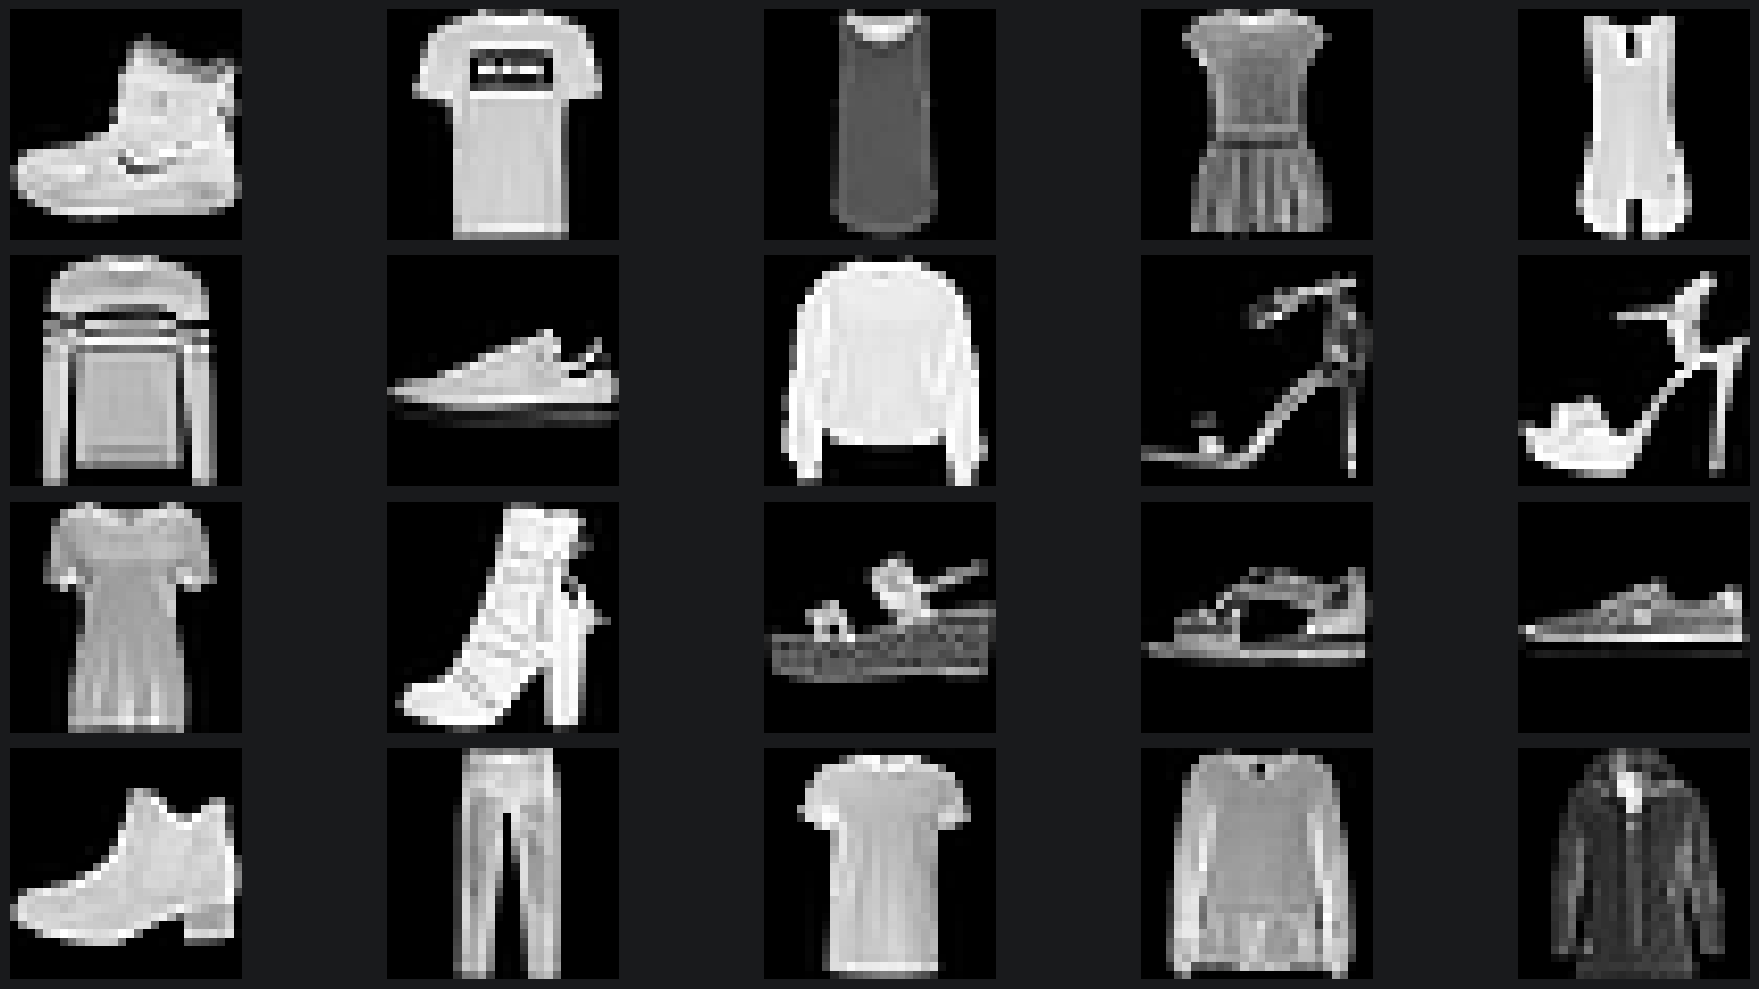

In [2]:
fashion_mnist = keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train_full = X_train_full.astype(np.float32) / 255
X_test = X_test.astype(np.float32) / 255
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

plot_images(X_train[:20], 4, 5)

## Stacked Autoencoder

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 4)              │       154,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 28, 28)         │       155,428 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 310,076 (1.18 MB)

 Trainable params: 310,076 (1.18 MB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


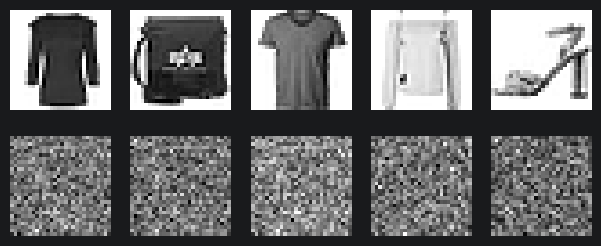

In [4]:
def rounded_accuracy(y_true, y_pred):
    return keras.metrics.binary_accuracy(tf.round(y_true), tf.round(y_pred))


code_size = 4
stacked_encoder = keras.models.Sequential(
        [
                keras.layers.Input(shape=[28, 28]),
                keras.layers.Flatten(),
                keras.layers.Dense(14 * 14, activation="selu"),
                keras.layers.Dense(code_size, activation="selu"),
                ]
        )
stacked_decoder = keras.models.Sequential(
        [
                keras.layers.Input(shape=[code_size]),
                keras.layers.Dense(196, activation="selu"),
                keras.layers.Dense(28 * 28, activation="sigmoid"),
                keras.layers.Reshape([28, 28])
                ]
        )
stacked_ae = keras.models.Sequential([stacked_encoder, stacked_decoder])
loss = "binary_crossentropy"
stacked_ae.compile(
        loss=loss, optimizer=keras.optimizers.SGD(learning_rate=1.5), metrics=[rounded_accuracy]
        )
stacked_ae.summary()
plot_reconstructions(stacked_ae, images=X_valid)

In [5]:
img = X_valid[0:3]
stacked_encoder.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step


array([[ 1.2466581 , -0.64548934, -1.1460959 , -0.64703035],
       [ 1.6496558 ,  0.20879419, -0.62196064, -0.10205825],
       [ 1.7817467 , -1.076101  , -0.8734819 ,  0.42983127]],
      dtype=float32)

In [6]:
y_pred = stacked_decoder.predict(stacked_encoder.predict(img))
y_pred.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step


(3, 28, 28)

Epoch 1/10
860/860 - 9s - 10ms/step - loss: 0.3442 - rounded_accuracy: 0.8820
Epoch 2/10
860/860 - 8s - 10ms/step - loss: 0.3259 - rounded_accuracy: 0.8966
Epoch 3/10
860/860 - 8s - 10ms/step - loss: 0.3211 - rounded_accuracy: 0.9004
Epoch 4/10
860/860 - 8s - 9ms/step - loss: 0.3185 - rounded_accuracy: 0.9021
Epoch 5/10
860/860 - 8s - 9ms/step - loss: 0.3165 - rounded_accuracy: 0.9036
Epoch 6/10
860/860 - 8s - 9ms/step - loss: 0.3153 - rounded_accuracy: 0.9045
Epoch 7/10
860/860 - 8s - 9ms/step - loss: 0.3140 - rounded_accuracy: 0.9055
Epoch 8/10
860/860 - 8s - 9ms/step - loss: 0.3132 - rounded_accuracy: 0.9062
Epoch 9/10
860/860 - 8s - 10ms/step - loss: 0.3122 - rounded_accuracy: 0.9068
Epoch 10/10
860/860 - 8s - 10ms/step - loss: 0.3116 - rounded_accuracy: 0.9073
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


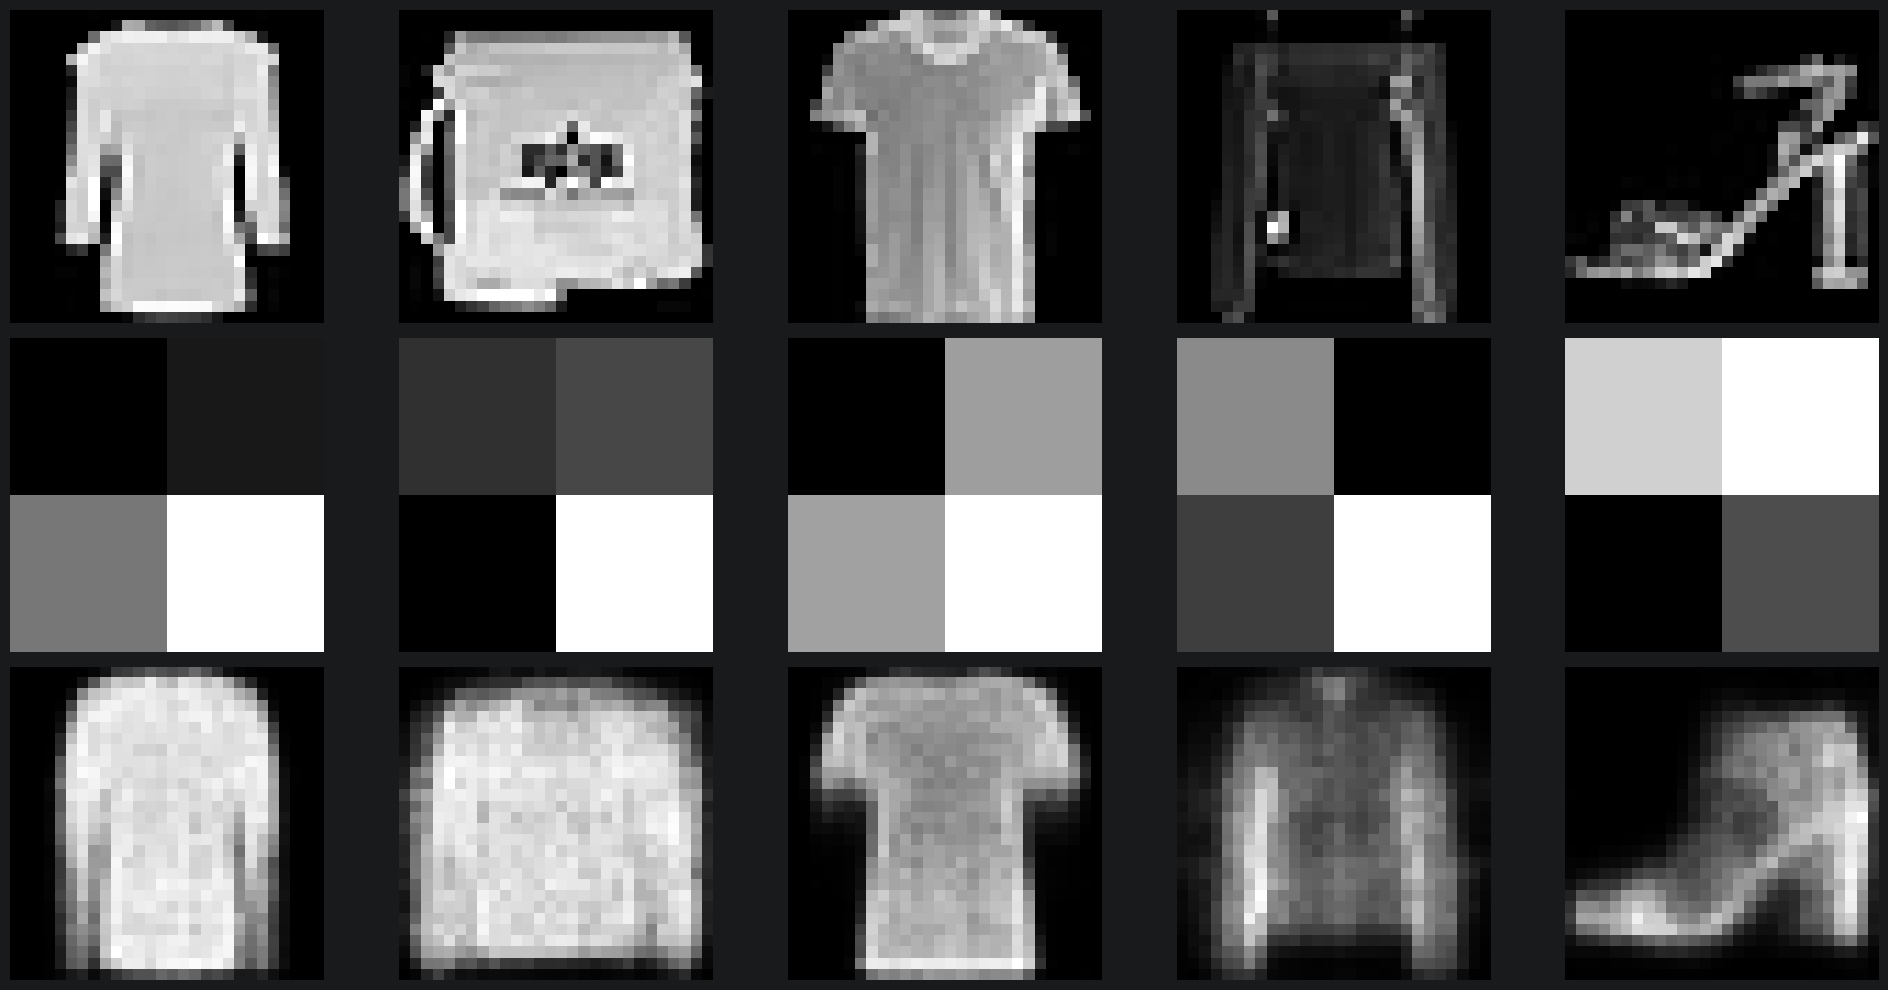

In [8]:
stacked_ae.fit(X_train, X_train, batch_size=64, epochs=10, verbose=2)
show_reconstructions_code(stacked_ae, X_valid, (2, 2), 5)

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_6 (Sequential)       │ (None, 16)             │       157,012 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_7 (Sequential)       │ (None, 28, 28)         │       157,780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 314,792 (1.20 MB)

 Trainable params: 314,792 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


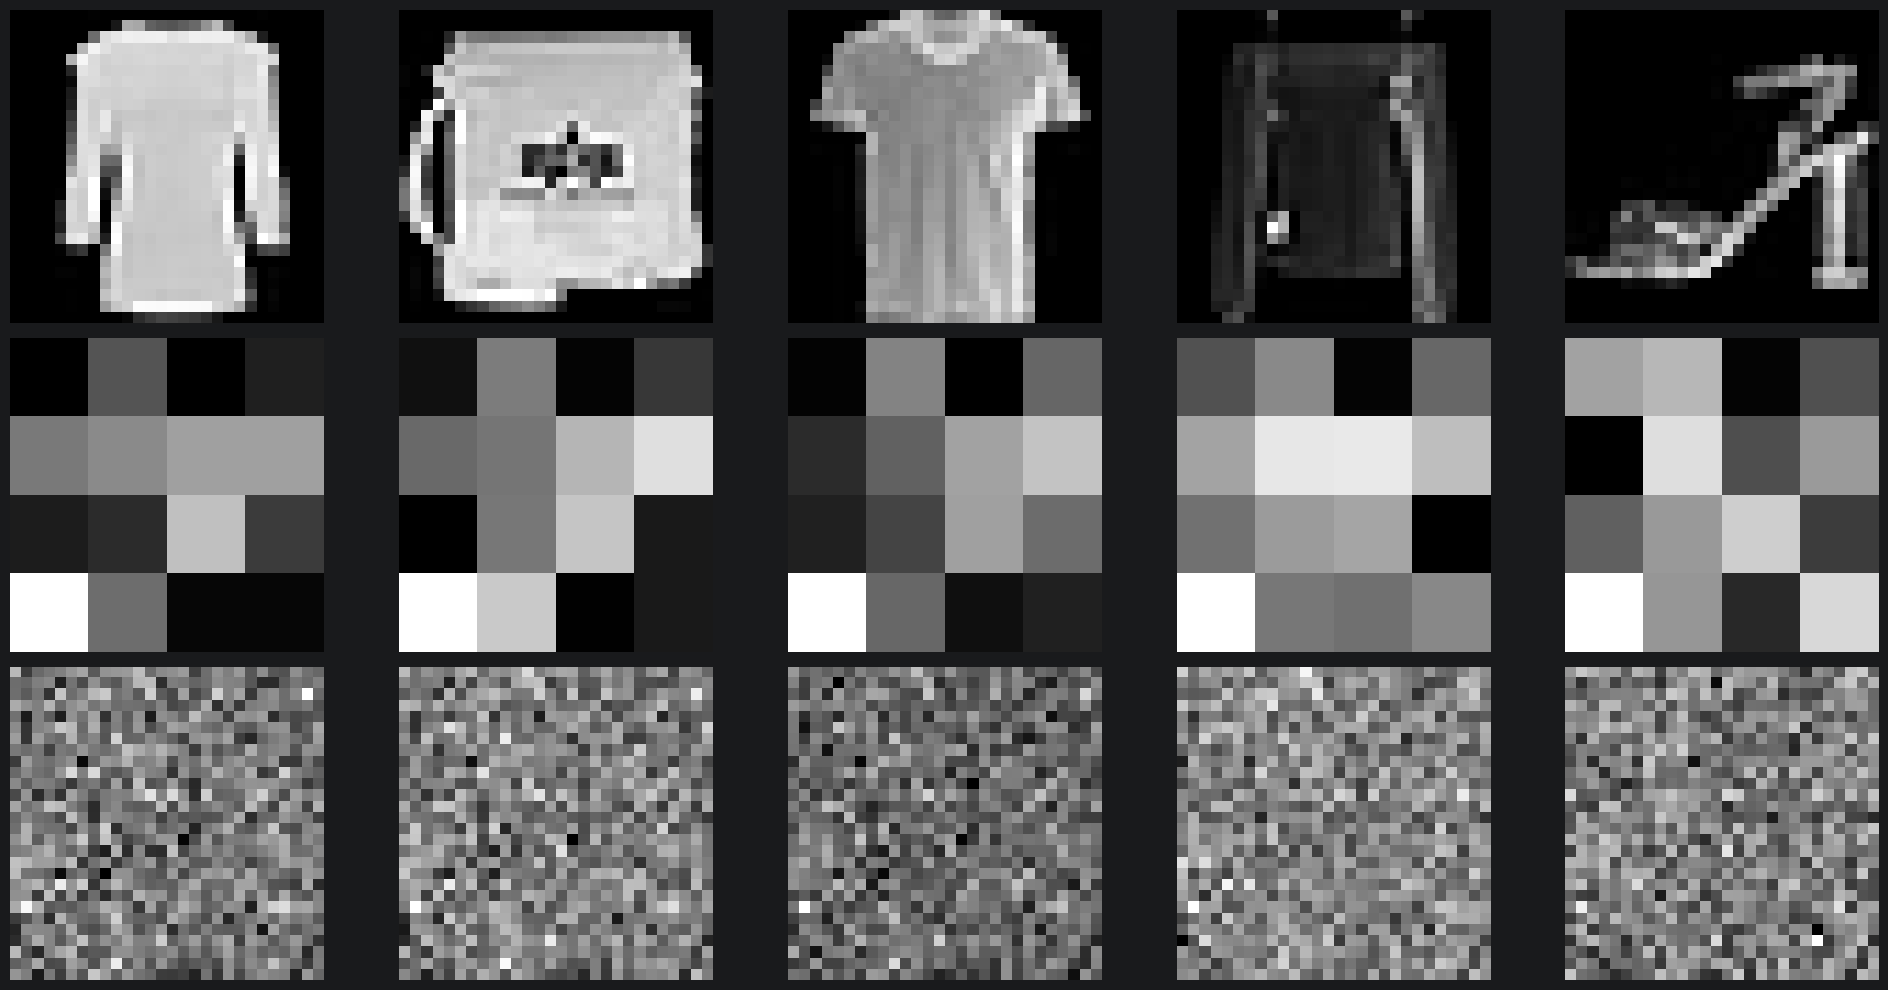

In [9]:
code_size = 16
stacked_encoder_16 = keras.models.Sequential(
        [
                keras.layers.Input(shape=[28, 28]),
                keras.layers.Flatten(),
                keras.layers.Dense(14 * 14, activation="selu"),
                keras.layers.Dense(code_size, activation="selu"),
                ]
        )
stacked_decoder_16 = keras.models.Sequential(
        [
                keras.layers.Input(shape=[code_size]),
                keras.layers.Dense(196, activation="selu"),
                keras.layers.Dense(28 * 28, activation="sigmoid"),
                keras.layers.Reshape([28, 28])
                ]
        )
stacked_ae_16 = keras.models.Sequential([stacked_encoder_16, stacked_decoder_16])
loss = "binary_crossentropy"
stacked_ae_16.compile(
        loss=loss, optimizer=keras.optimizers.SGD(learning_rate=1.5), metrics=[rounded_accuracy]
        )
stacked_ae_16.summary()
show_reconstructions_code(stacked_ae_16, X_valid, (4, 4), 5)

In [10]:
stacked_encoder_16.predict(X_valid[:4]).shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step


(4, 16)

Epoch 1/10
860/860 - 8s - 10ms/step - loss: 0.3652 - rounded_accuracy: 0.8651
Epoch 2/10
860/860 - 8s - 9ms/step - loss: 0.3187 - rounded_accuracy: 0.9037
Epoch 3/10
860/860 - 8s - 9ms/step - loss: 0.3125 - rounded_accuracy: 0.9090
Epoch 4/10
860/860 - 8s - 9ms/step - loss: 0.3088 - rounded_accuracy: 0.9119
Epoch 5/10
860/860 - 8s - 10ms/step - loss: 0.3059 - rounded_accuracy: 0.9143
Epoch 6/10
860/860 - 8s - 10ms/step - loss: 0.3040 - rounded_accuracy: 0.9156
Epoch 7/10
860/860 - 8s - 10ms/step - loss: 0.3024 - rounded_accuracy: 0.9169
Epoch 8/10
860/860 - 8s - 9ms/step - loss: 0.3012 - rounded_accuracy: 0.9178
Epoch 9/10
860/860 - 8s - 10ms/step - loss: 0.3002 - rounded_accuracy: 0.9187
Epoch 10/10
860/860 - 8s - 9ms/step - loss: 0.2992 - rounded_accuracy: 0.9194
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


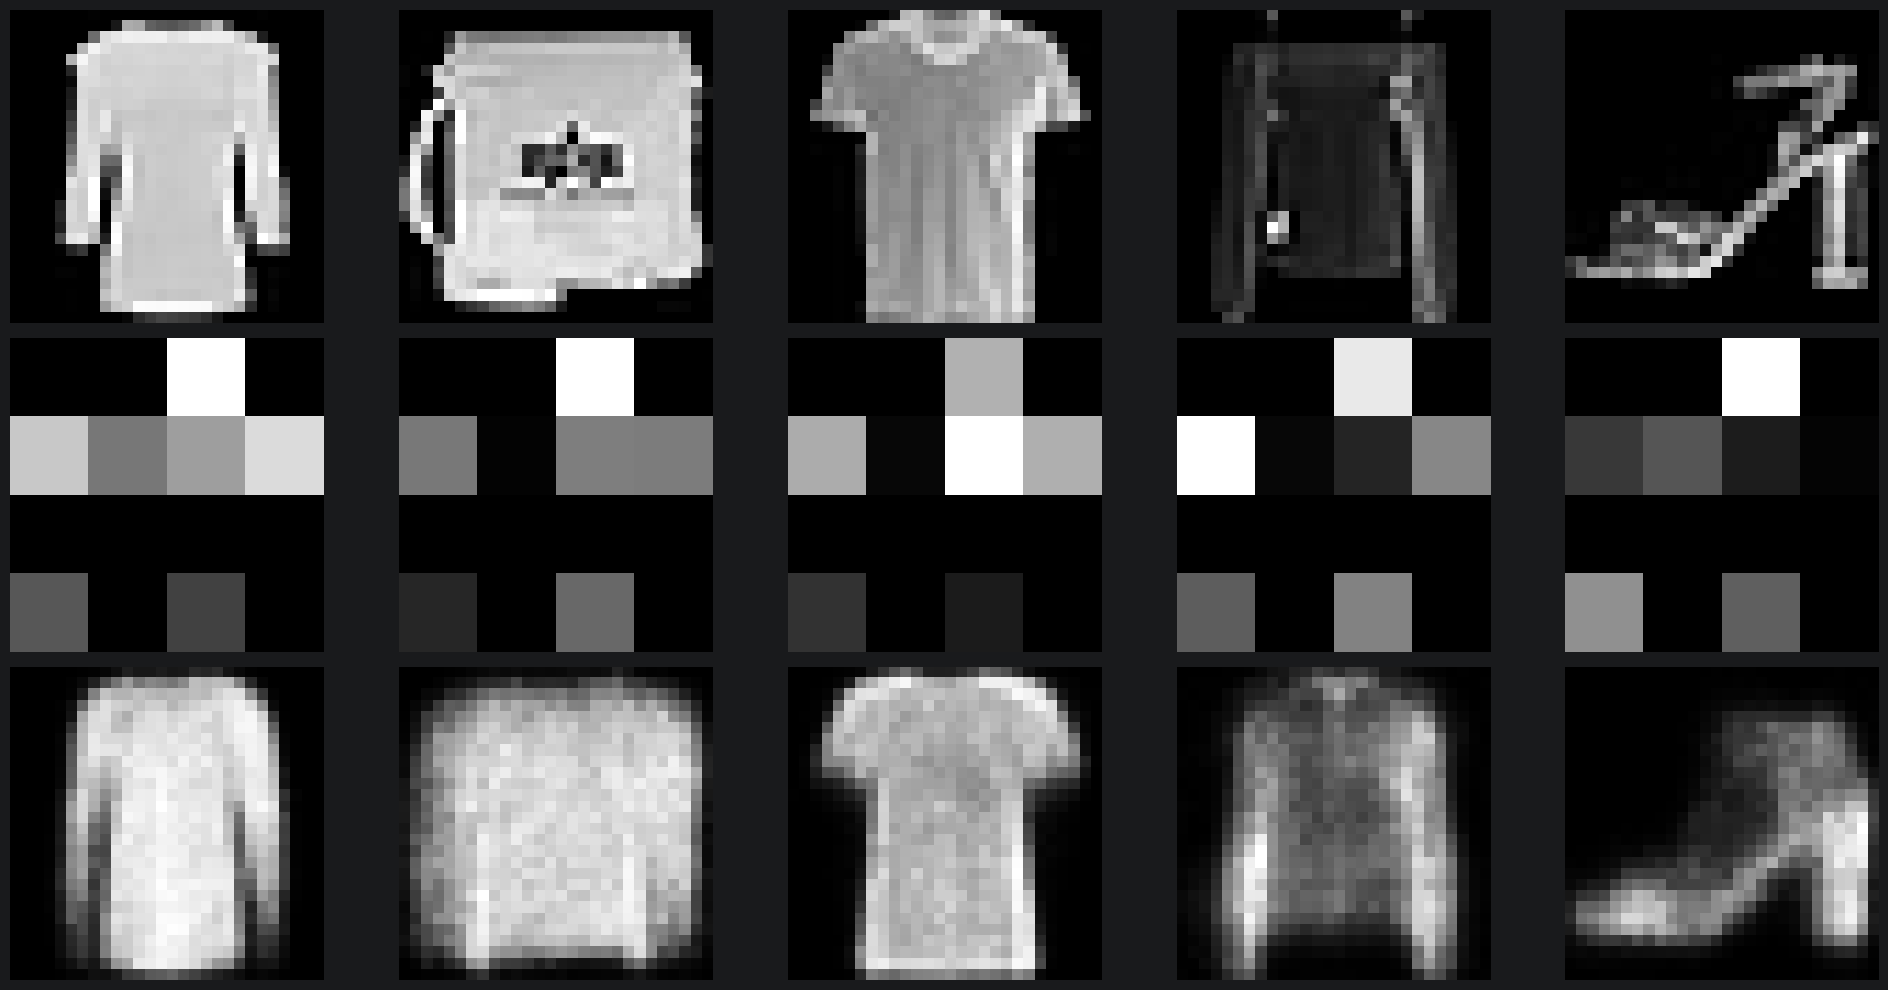

In [11]:
early_stopping = keras.callbacks.EarlyStopping(
        monitor="rounded_accuracy",
        patience=2,
        min_delta=0.001,
        mode="max",
        restore_best_weights=True
        )
stacked_ae_16.fit(X_train, X_train, batch_size=64, epochs=10, verbose=2, callbacks=[early_stopping])
show_reconstructions_code(stacked_ae_16, X_valid, (4, 4), 5)

In [12]:
print(stacked_ae.evaluate(X_test, X_test))
print(stacked_ae_16.evaluate(X_test, X_test))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.3128 - rounded_accuracy: 0.9066
[0.3128420114517212, 0.906609058380127]
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3021 - rounded_accuracy: 0.9164
[0.3020658493041992, 0.9163859486579895]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


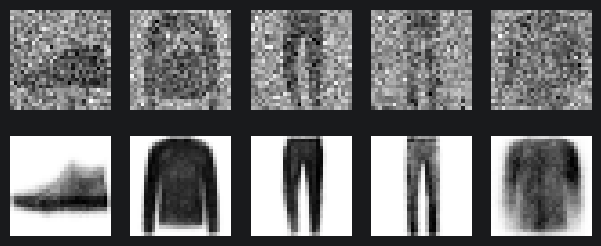

In [13]:
noise_layer = keras.layers.GaussianNoise(0.4)
X_noise = noise_layer(X_test, training=True).numpy()
plot_reconstructions(stacked_ae_16, images=X_noise[:10])

## Denoising Autoencoder

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_9 (Sequential)       │ (None, 16)             │       157,012 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_10 (Sequential)      │ (None, 28, 28)         │       157,780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 314,792 (1.20 MB)

 Trainable params: 314,792 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


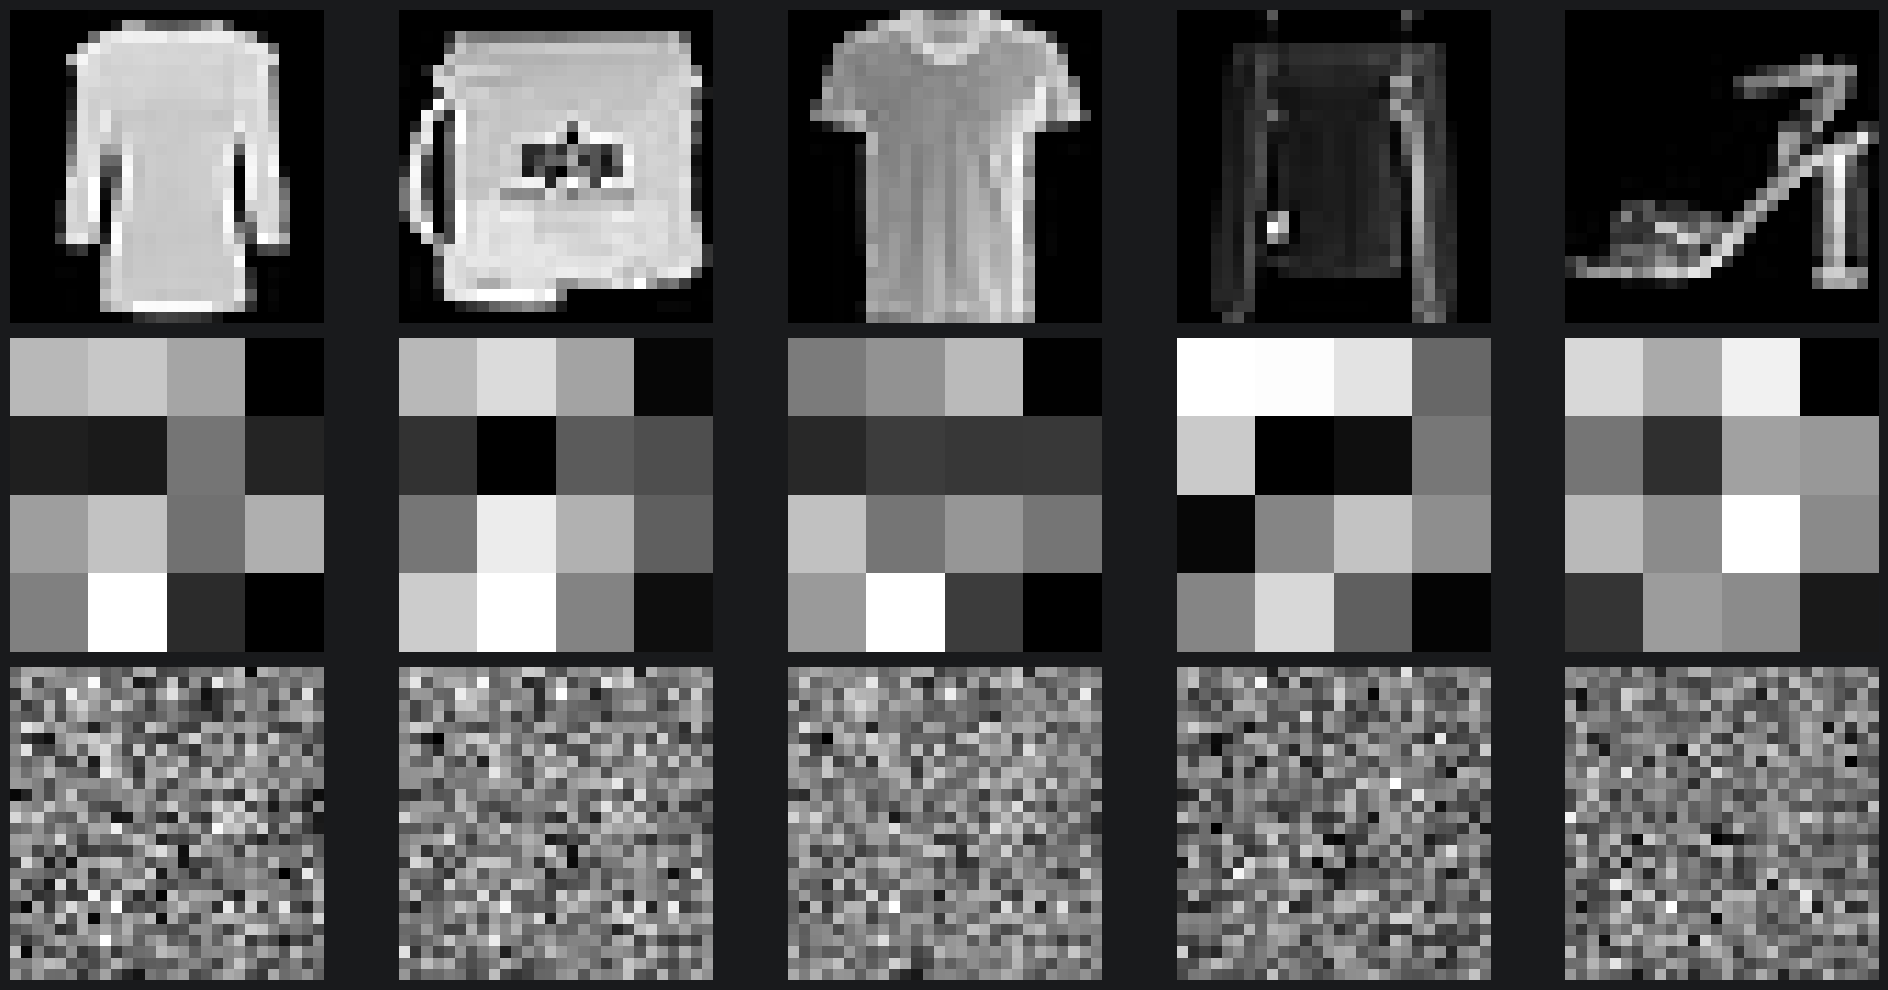

In [14]:
code_size = 16
stacked_encoder_noise = keras.models.Sequential(
        [
                keras.layers.Input(shape=[28, 28]),
                keras.layers.Flatten(),
                keras.layers.GaussianNoise(0.4),
                keras.layers.Dense(14 * 14, activation="selu"),
                keras.layers.Dense(code_size, activation="selu"),
                ]
        )
stacked_decoder_noise = keras.models.Sequential(
        [
                keras.layers.Input(shape=[code_size]),
                keras.layers.Dense(196, activation="selu"),
                keras.layers.Dense(28 * 28, activation="sigmoid"),
                keras.layers.Reshape([28, 28])
                ]
        )
denoising_ae = keras.models.Sequential([stacked_encoder_noise, stacked_decoder_noise])
loss = "binary_crossentropy"
denoising_ae.compile(
        loss=loss, optimizer=keras.optimizers.SGD(learning_rate=1.5), metrics=[rounded_accuracy]
        )
denoising_ae.summary()
show_reconstructions_code(denoising_ae, X_valid, (4, 4), 5)

Epoch 1/10
860/860 - 9s - 10ms/step - loss: 0.3672 - rounded_accuracy: 0.8639
Epoch 2/10
860/860 - 8s - 10ms/step - loss: 0.3233 - rounded_accuracy: 0.9000
Epoch 3/10
860/860 - 9s - 11ms/step - loss: 0.3178 - rounded_accuracy: 0.9043
Epoch 4/10
860/860 - 9s - 10ms/step - loss: 0.3149 - rounded_accuracy: 0.9069
Epoch 5/10
860/860 - 9s - 10ms/step - loss: 0.3129 - rounded_accuracy: 0.9082
Epoch 6/10
860/860 - 10s - 11ms/step - loss: 0.3113 - rounded_accuracy: 0.9097
Epoch 7/10
860/860 - 9s - 11ms/step - loss: 0.3102 - rounded_accuracy: 0.9105
Epoch 8/10
860/860 - 9s - 10ms/step - loss: 0.3091 - rounded_accuracy: 0.9114
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


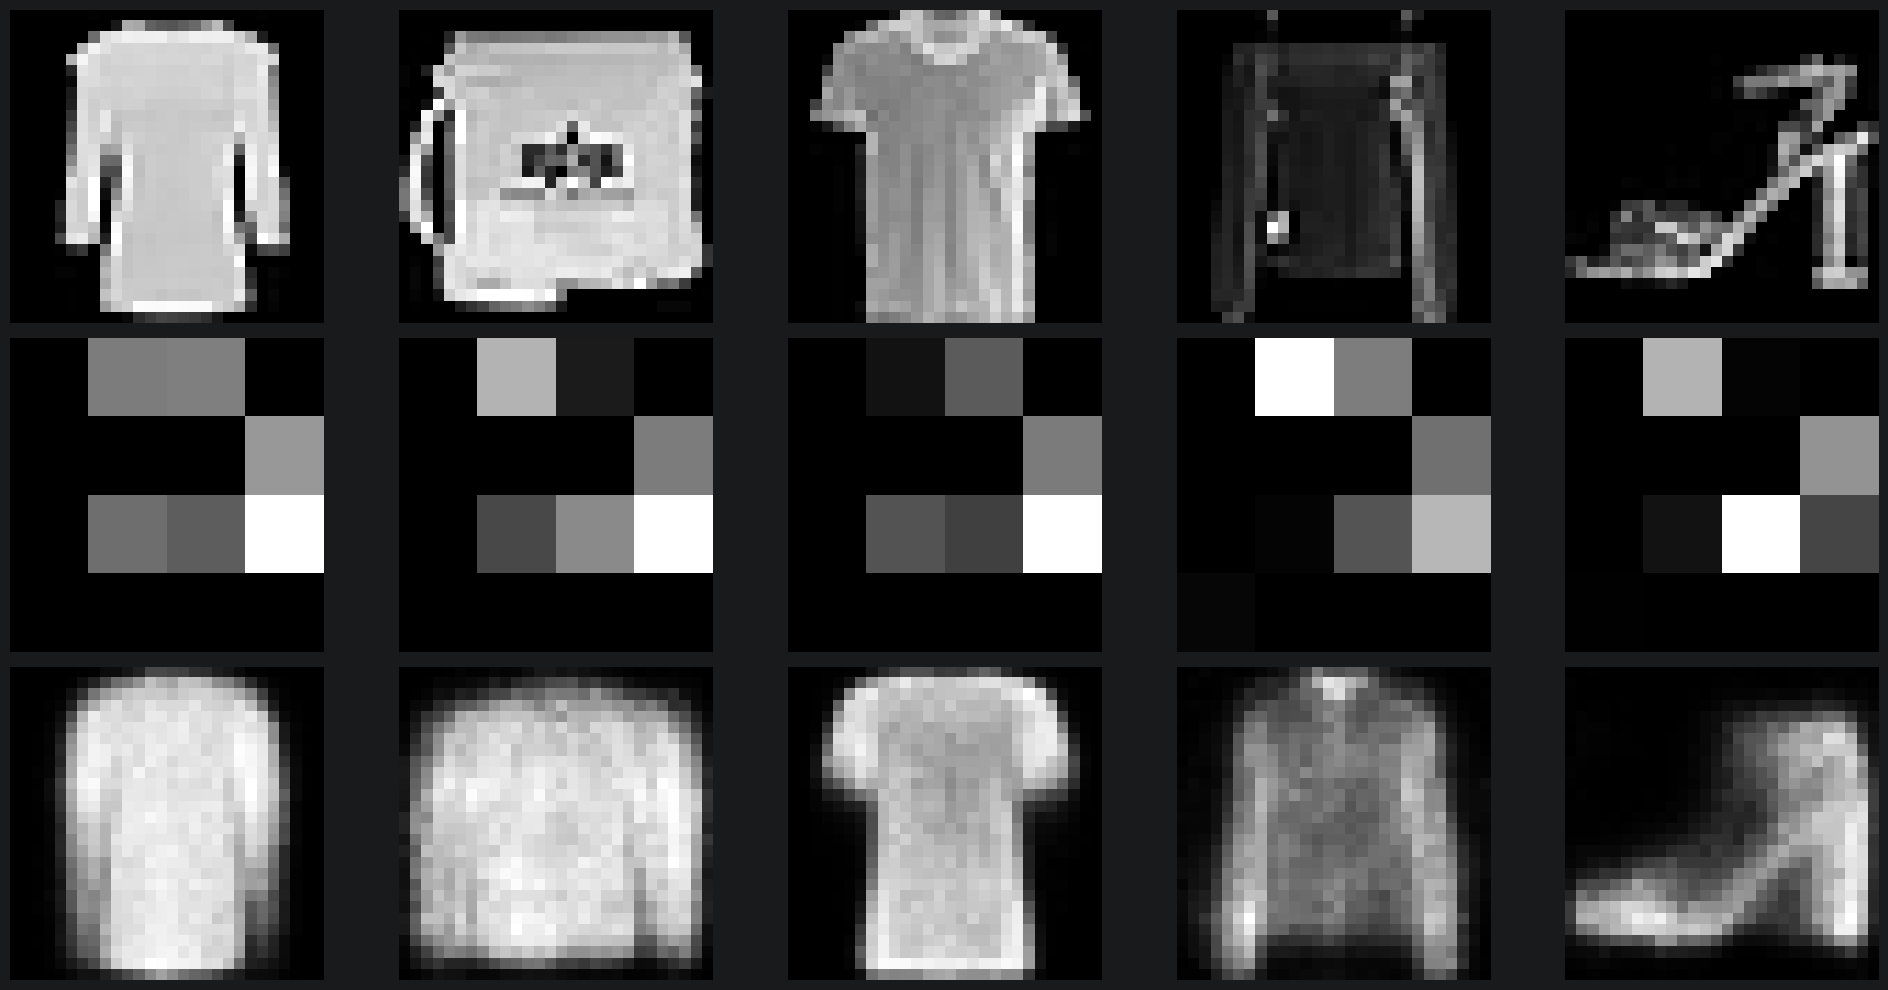

In [15]:
early_stopping = keras.callbacks.EarlyStopping(
        monitor="rounded_accuracy",
        patience=2,
        min_delta=0.002,
        mode="max",
        restore_best_weights=True
        )
denoising_ae.fit(X_train, X_train, batch_size=64, epochs=10, verbose=2, callbacks=[early_stopping])
show_reconstructions_code(denoising_ae, X_valid, (4, 4), 5)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


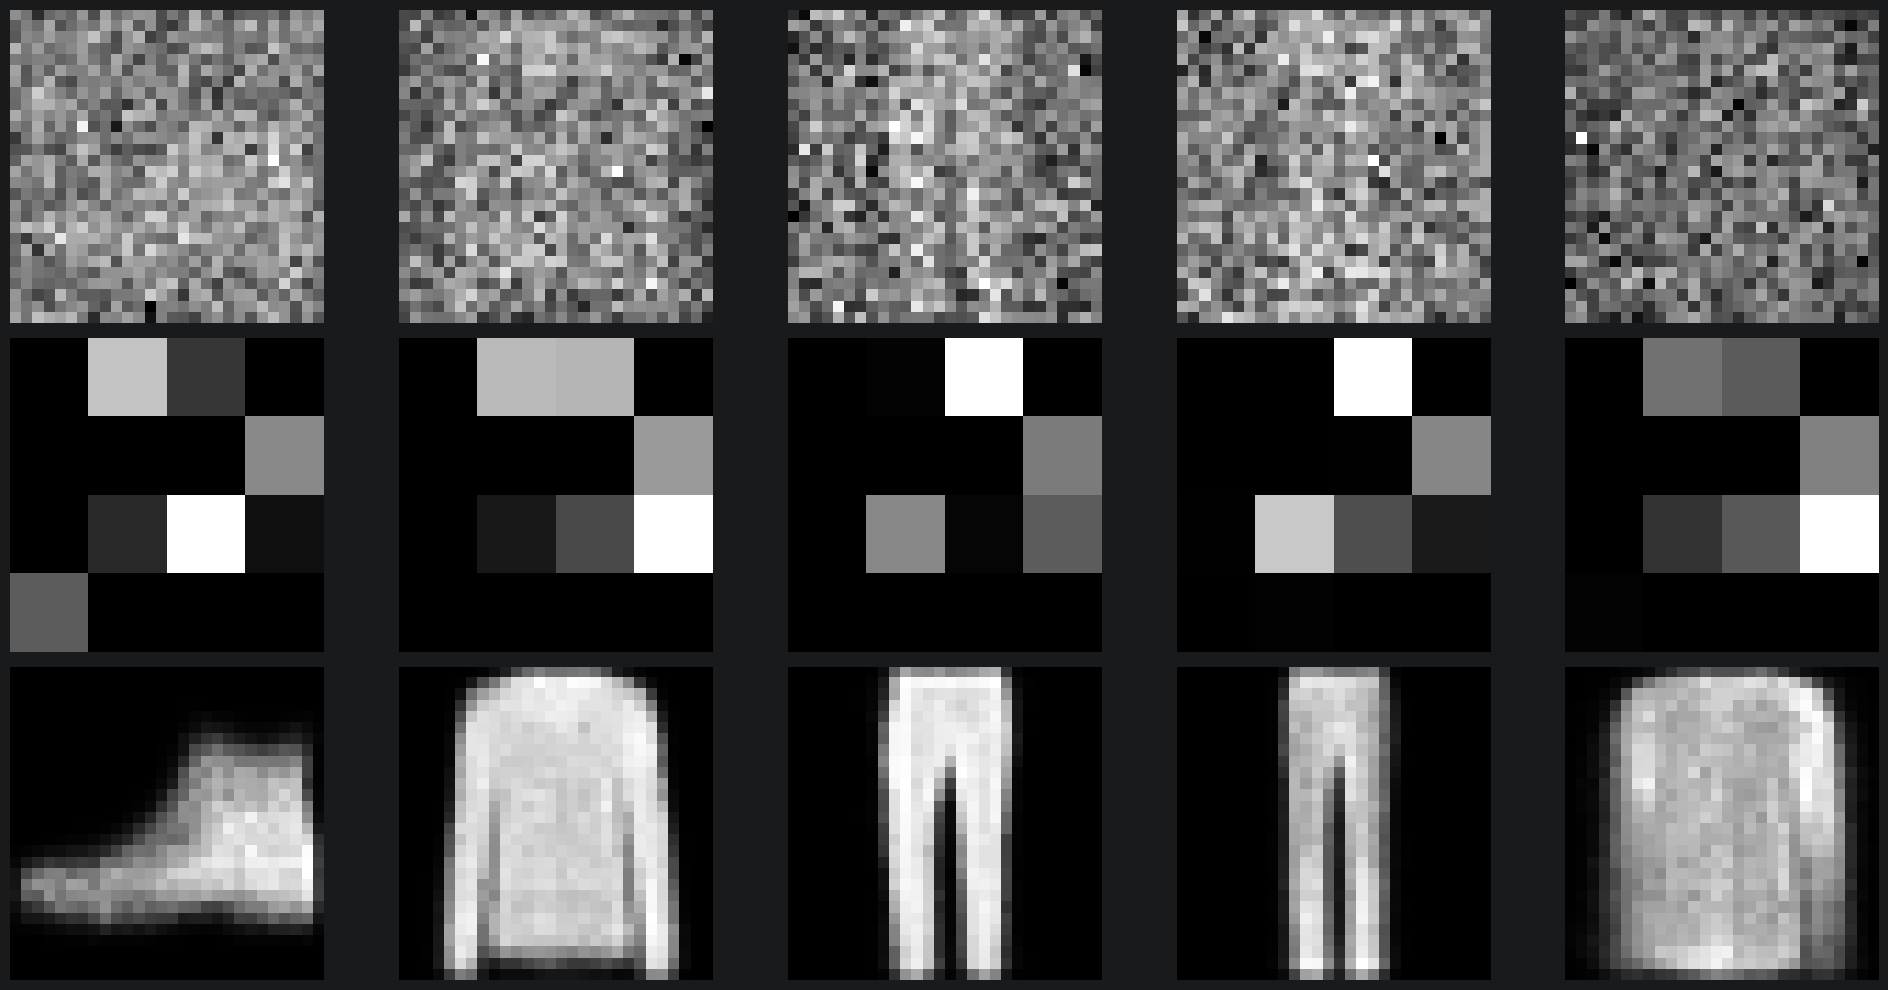

In [16]:

noise_layer = keras.layers.GaussianNoise(0.8)
X_noise = noise_layer(X_test, training=True).numpy()
show_reconstructions_code(denoising_ae, X_noise, (4, 4), 5)

## Denoising Autoencoder mit Wiederverwendung des Encoders

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_14 (Sequential)      │ (None, 16)             │       157,012 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_7 (Sequential)       │ (None, 28, 28)         │       157,780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 314,792 (1.20 MB)

 Trainable params: 157,012 (613.33 KB)

 Non-trainable params: 157,780 (616.33 KB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


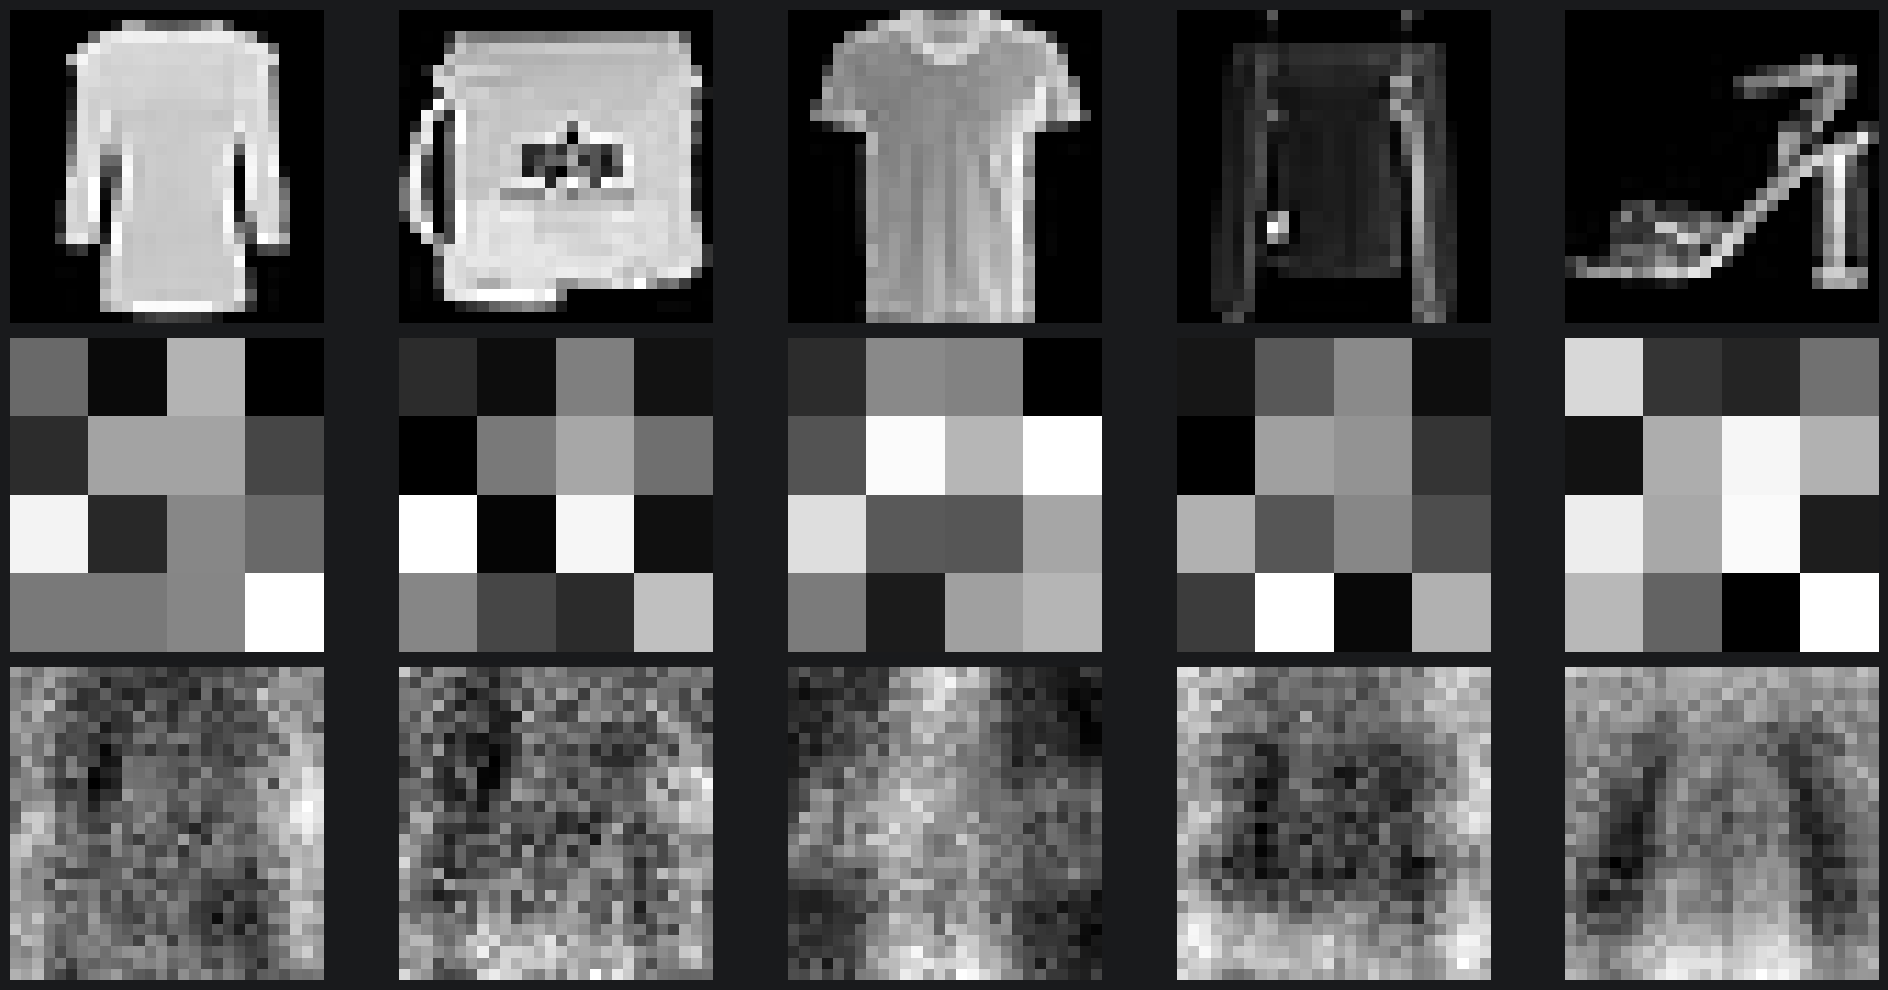

In [19]:
code_size = 16
stacked_encoder_reuse = keras.models.Sequential(
        [
                keras.layers.Input(shape=[28, 28]),
                keras.layers.Flatten(),
                keras.layers.GaussianNoise(0.4),
                keras.layers.Dense(14 * 14, activation="selu"),
                keras.layers.Dense(code_size, activation="selu"),
                ]
        )

denoising_ae_reuse = keras.models.Sequential([stacked_encoder_reuse, stacked_decoder_16])
stacked_decoder_16.trainable = False
loss = "binary_crossentropy"
denoising_ae_reuse.compile(
        loss=loss, optimizer=keras.optimizers.SGD(learning_rate=1.5), metrics=[rounded_accuracy]
        )
denoising_ae_reuse.summary()
show_reconstructions_code(denoising_ae_reuse, X_valid, (4, 4), 5)

Epoch 1/10
860/860 - 8s - 9ms/step - loss: 0.3247 - rounded_accuracy: 0.8993
Epoch 2/10
860/860 - 8s - 9ms/step - loss: 0.3105 - rounded_accuracy: 0.9107
Epoch 3/10
860/860 - 8s - 9ms/step - loss: 0.3090 - rounded_accuracy: 0.9118
Epoch 4/10
860/860 - 8s - 9ms/step - loss: 0.3082 - rounded_accuracy: 0.9123
Epoch 5/10
860/860 - 8s - 10ms/step - loss: 0.3074 - rounded_accuracy: 0.9131
Epoch 6/10
860/860 - 8s - 9ms/step - loss: 0.3069 - rounded_accuracy: 0.9134
Epoch 7/10
860/860 - 9s - 10ms/step - loss: 0.3064 - rounded_accuracy: 0.9137
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


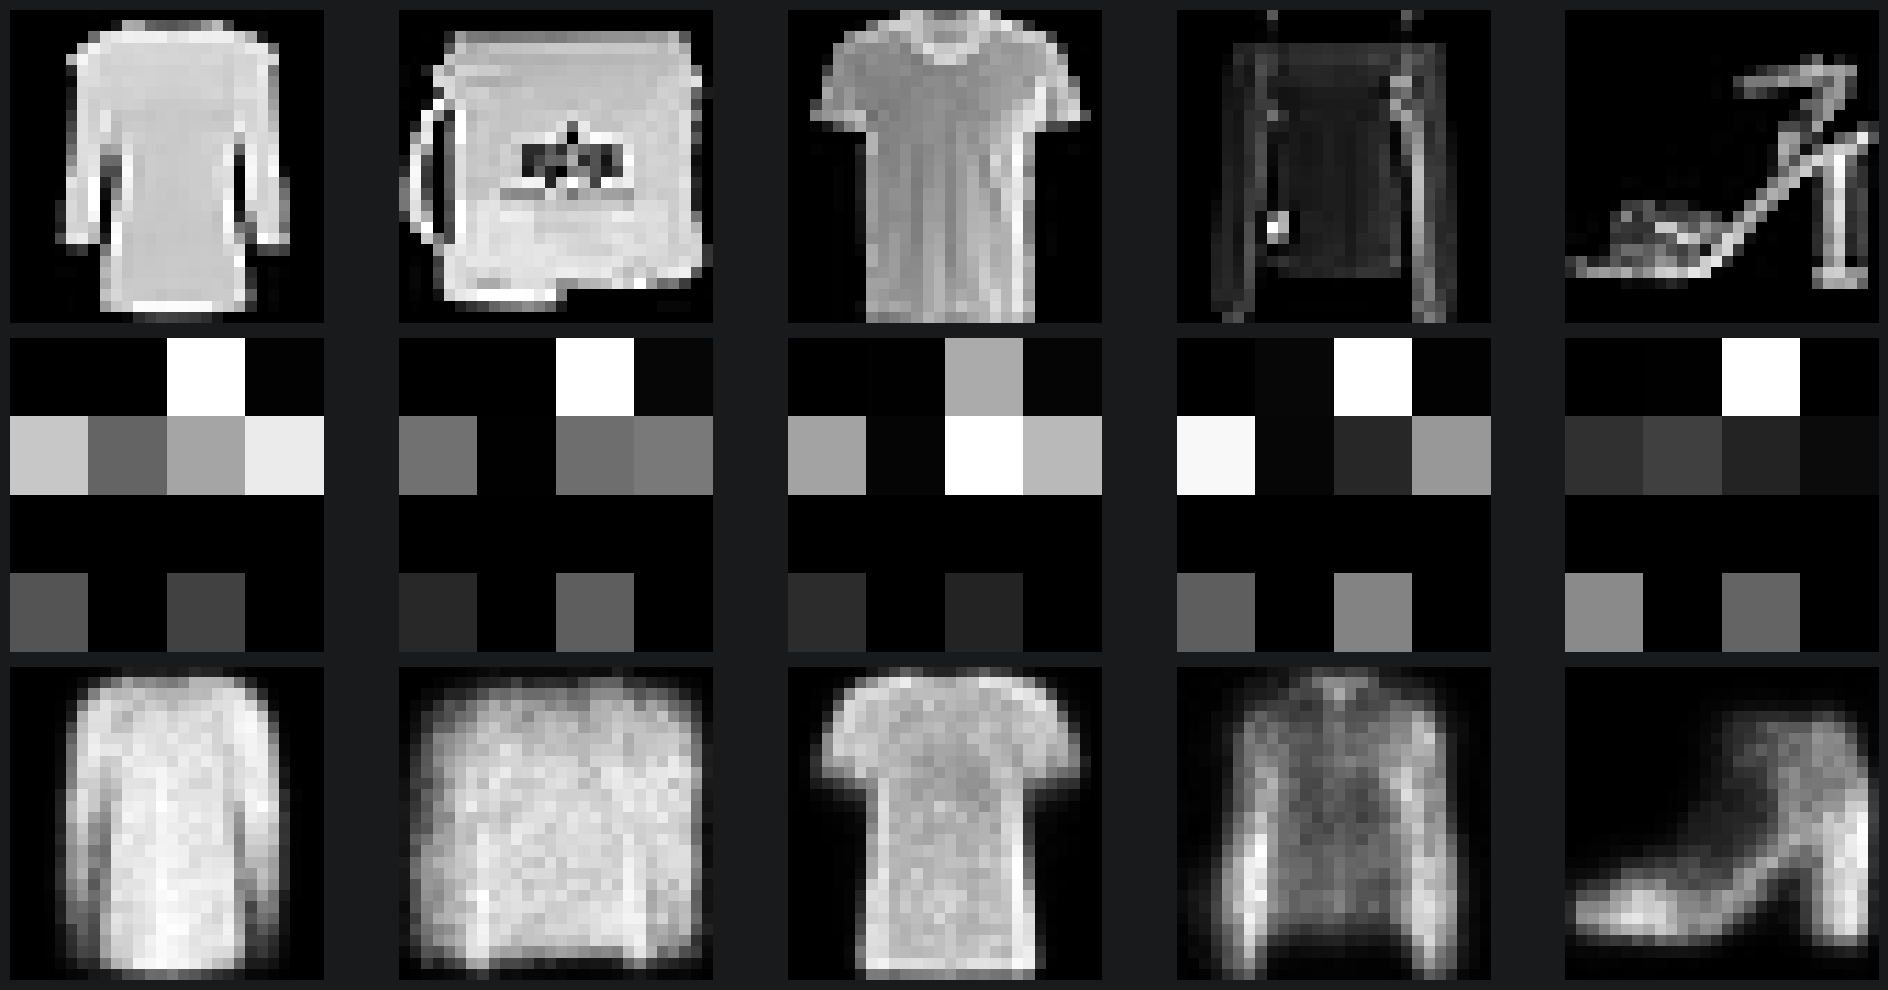

In [20]:
early_stopping = keras.callbacks.EarlyStopping(
        monitor="rounded_accuracy",
        patience=2,
        min_delta=0.001,
        mode="max",
        restore_best_weights=True
        )
denoising_ae_reuse.fit(X_train, X_train, batch_size=64, epochs=10, verbose=2, callbacks=[early_stopping])
show_reconstructions_code(denoising_ae_reuse, X_valid, (4, 4), 5)

## Auf Codes Klassifikator trainieren

In [21]:
codes = stacked_encoder_16.predict(X_train)
print(codes.shape)
dataset = tf.data.Dataset.from_tensor_slices((codes, y_train)).batch(64).prefetch(tf.data.AUTOTUNE)

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
(55000, 16)


In [29]:
code_classifier = keras.Sequential(
        [
                keras.layers.Input(shape=[16]),
                keras.layers.Dense(16, activation="relu"),
                keras.layers.Dense(10, activation="softmax")
                ]
        )
code_classifier.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
code_classifier.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_26 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 442 (1.73 KB)

 Trainable params: 442 (1.73 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
early_stopping = keras.callbacks.EarlyStopping(
        monitor="loss",
        patience=2,
        min_delta=0.001
        )
code_classifier.fit(dataset, epochs=10, verbose=2, callbacks=[early_stopping])

Epoch 1/10
860/860 - 5s - 6ms/step - accuracy: 0.5378 - loss: 2.1506
Epoch 2/10
860/860 - 5s - 6ms/step - accuracy: 0.7261 - loss: 0.7331
Epoch 3/10
860/860 - 5s - 6ms/step - accuracy: 0.7390 - loss: 0.6941
Epoch 4/10
860/860 - 5s - 6ms/step - accuracy: 0.7435 - loss: 0.6828
Epoch 5/10
860/860 - 5s - 6ms/step - accuracy: 0.7455 - loss: 0.6767
Epoch 6/10
860/860 - 5s - 5ms/step - accuracy: 0.7464 - loss: 0.6742
Epoch 7/10
860/860 - 5s - 6ms/step - accuracy: 0.7471 - loss: 0.6734
Epoch 8/10
860/860 - 5s - 6ms/step - accuracy: 0.7466 - loss: 0.6733


In [31]:
test_code = stacked_encoder_16.predict(X_test)
code_classifier.evaluate(test_code, y_test, verbose=2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 - 1s - 4ms/step - accuracy: 0.7475 - loss: 0.6862


[0.6862232089042664, 0.7475000023841858]

## Klassifikator mit vortrainiertem Encoder bauen

In [34]:
image_classifier = keras.Sequential(
        [
                stacked_encoder_16,
                code_classifier
                ]
        )
image_classifier.compile(
        loss="sparse_categorical_crossentropy",  # oder passend zu y_test
        metrics=["accuracy"]
        )
image_classifier.evaluate(X_test, y_test, verbose=2)

313/313 - 2s - 5ms/step - accuracy: 0.7475 - loss: 0.6862


[0.6862232089042664, 0.7475000023841858]

## Klassifikation mit vortrainiertem Encoder

In [27]:
encoder_classifier = keras.Sequential(
        [
                stacked_encoder_16,
                keras.layers.Dense(16, activation="relu"),
                keras.layers.Dense(10, activation="softmax")
                ]
        )
stacked_encoder_16.trainable = False
encoder_classifier.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
encoder_classifier.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_6 (Sequential)       │ (None, 16)             │       157,012 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 157,454 (615.05 KB)

 Trainable params: 442 (1.73 KB)

 Non-trainable params: 157,012 (613.33 KB)

In [28]:
early_stopping = keras.callbacks.EarlyStopping(
        monitor="loss",
        patience=2,
        min_delta=0.001
        )
encoder_classifier.fit(X_train, y_train, epochs=10, verbose=2, callbacks=[early_stopping])

Epoch 1/10
1719/1719 - 12s - 7ms/step - accuracy: 0.6179 - loss: 1.4578
Epoch 2/10
1719/1719 - 11s - 6ms/step - accuracy: 0.7408 - loss: 0.6998
Epoch 3/10
1719/1719 - 13s - 7ms/step - accuracy: 0.7442 - loss: 0.6815
Epoch 4/10
1719/1719 - 12s - 7ms/step - accuracy: 0.7451 - loss: 0.6796
Epoch 5/10
1719/1719 - 12s - 7ms/step - accuracy: 0.7443 - loss: 0.6793
Epoch 6/10
1719/1719 - 14s - 8ms/step - accuracy: 0.7433 - loss: 0.6794


In [33]:
encoder_classifier.evaluate(X_test, y_test, verbose=2)

313/313 - 2s - 8ms/step - accuracy: 0.7319 - loss: 0.7115


[0.7115187644958496, 0.7318999767303467]